In [1]:
import sys

In [2]:
sys.path.append('../')

In [3]:
import my_functions

In [4]:
from sklearn.datasets import make_blobs


In [5]:
import imblearn.over_sampling

In [7]:
for item in dir(imblearn.over_sampling):
    if 'SMOTE' in item:
        print(item)

BorderlineSMOTE
KMeansSMOTE
SMOTE
SMOTEN
SMOTENC
SVMSMOTE


In [11]:
from imblearn.over_sampling import BorderlineSMOTE

In [9]:
import imblearn

In [10]:
for item in dir(imblearn):
    if 'over' in item:
        print(item)

over_sampling


In [12]:
?BorderlineSMOTE

Init signature:
BorderlineSMOTE(
    *,
    sampling_strategy='auto',
    random_state=None,
    k_neighbors=5,
    m_neighbors=10,
    kind='borderline-1',
)
Docstring:     
Over-sampling using Borderline SMOTE.

This algorithm is a variant of the original SMOTE algorithm proposed in
[2]_. Borderline samples will be detected and used to generate new
synthetic samples.

Read more in the :ref:`User Guide <smote_adasyn>`.

.. versionadded:: 0.4

Parameters
----------
sampling_strategy : float, str, dict or callable, default='auto'
    Sampling information to resample the data set.

    - When ``float``, it corresponds to the desired ratio of the number of
      samples in the minority class over the number of samples in the
      majority class after resampling. Therefore, the ratio is expressed as
      :math:`\alpha_{os} = N_{rm} / N_{M}` where :math:`N_{rm}` is the
      number of samples in the minority class after resampling and
      :math:`N_{M}` is the number of samples in the ma

In [13]:
blobs_random_seed = 42
centers = [(0,0), (5,5)]
cluster_std = 1.5
n_features = 2
n_samples = 1600

In [16]:
X,y  = make_blobs(
    n_samples=n_samples,
    n_features=n_features,
    centers=centers,
    cluster_std=cluster_std,
    random_state=0,
)

X,y = pd.DataFrame(X, columns=['varA', 'varB']), pd.Series(y)

In [17]:
X.shape, y.shape

((1600, 2), (1600,))

In [18]:
data1 = X[y==0]
data2 = X[y==1].sample(200, random_state=42)

In [19]:
X = pd.concat([data1, data2], axis=0)


In [20]:
X.shape, y.shape

((1000, 2), (1600,))

In [22]:
y = y.loc[X.index]
X.shape, y.shape

((1000, 2), (1000,))

# Borderline SMOTE

In [23]:
for item in dir(imblearn.over_sampling):
    if 'SMOTE' in item:
        print(item)

BorderlineSMOTE
KMeansSMOTE
SMOTE
SMOTEN
SMOTENC
SVMSMOTE


In [24]:
from imblearn.over_sampling import BorderlineSMOTE


In [25]:
?BorderlineSMOTE



Init signature:
BorderlineSMOTE(
    *,
    sampling_strategy='auto',
    random_state=None,
    k_neighbors=5,
    m_neighbors=10,
    kind='borderline-1',
)
Docstring:     
Over-sampling using Borderline SMOTE.

This algorithm is a variant of the original SMOTE algorithm proposed in
[2]_. Borderline samples will be detected and used to generate new
synthetic samples.

Read more in the :ref:`User Guide <smote_adasyn>`.

.. versionadded:: 0.4

Parameters
----------
sampling_strategy : float, str, dict or callable, default='auto'
    Sampling information to resample the data set.

    - When ``float``, it corresponds to the desired ratio of the number of
      samples in the minority class over the number of samples in the
      majority class after resampling. Therefore, the ratio is expressed as
      :math:`\alpha_{os} = N_{rm} / N_{M}` where :math:`N_{rm}` is the
      number of samples in the minority class after resampling and
      :math:`N_{M}` is the number of samples in the ma

In [26]:
sm_b1 = BorderlineSMOTE(
    sampling_strategy='auto',
    random_state=0,
    k_neighbors=5,
    m_neighbors=10,
    kind='borderline-1',
)

In [27]:
X_res_b1, y_res_b1 = sm_b1.fit_resample(X,y)

In [28]:
X.shape, X_res_b1.shape

((1000, 2), (1600, 2))

In [29]:
y.value_counts(), y_res_b1.value_counts()

(0    800
 1    200
 Name: count, dtype: int64,
 0    800
 1    800
 Name: count, dtype: int64)

In [31]:
help(BorderlineSMOTE)

Help on class BorderlineSMOTE in module imblearn.over_sampling._smote.filter:

class BorderlineSMOTE(imblearn.over_sampling._smote.base.BaseSMOTE)
 |  BorderlineSMOTE(*, sampling_strategy='auto', random_state=None, k_neighbors=5, m_neighbors=10, kind='borderline-1')
 |  
 |  Over-sampling using Borderline SMOTE.
 |  
 |  This algorithm is a variant of the original SMOTE algorithm proposed in
 |  [2]_. Borderline samples will be detected and used to generate new
 |  synthetic samples.
 |  
 |  Read more in the :ref:`User Guide <smote_adasyn>`.
 |  
 |  .. versionadded:: 0.4
 |  
 |  Parameters
 |  ----------
 |  sampling_strategy : float, str, dict or callable, default='auto'
 |      Sampling information to resample the data set.
 |  
 |      - When ``float``, it corresponds to the desired ratio of the number of
 |        samples in the minority class over the number of samples in the
 |        majority class after resampling. Therefore, the ratio is expressed as
 |        :math:`\alpha

In [32]:
#Defail for the smote borderline is borderline 1, in this one we modify it to borderline2

sm_b2 = BorderlineSMOTE(
    sampling_strategy='auto',
    random_state=0,
    k_neighbors=5,
    m_neighbors=10,
    kind='borderline-2',
)

In [33]:
X_res_b2, y_res_b2 = sm_b2.fit_resample(X,y)

In [34]:
X.shape, X_res_b1.shape, X_res_b2.shape

((1000, 2), (1600, 2), (1600, 2))

In [35]:
y.value_counts(), y_res_b1.value_counts(), y_res_b2.value_counts()

(0    800
 1    200
 Name: count, dtype: int64,
 0    800
 1    800
 Name: count, dtype: int64,
 0    800
 1    800
 Name: count, dtype: int64)

In [36]:
from my_functions import Scatterplot

In [37]:
?Scatterplot

Signature: Scatterplot(data1, class1, data2, class2, alpha=None)
Docstring:
Plot 2 Scatterplots.
1 Row and 2 columns, given the 2 provided datasets
Ex:

Without alpha:
>>>Scatterplot(X, y, X_resampled, y_resampled)

With alpha:
>>>Scatterplot(X, y, X_resampled, y_resampled, alpha=0.5)
File:      ~/Udemy/Udemy/machine_learning_imbalanced_data/my_functions.py
Type:      function

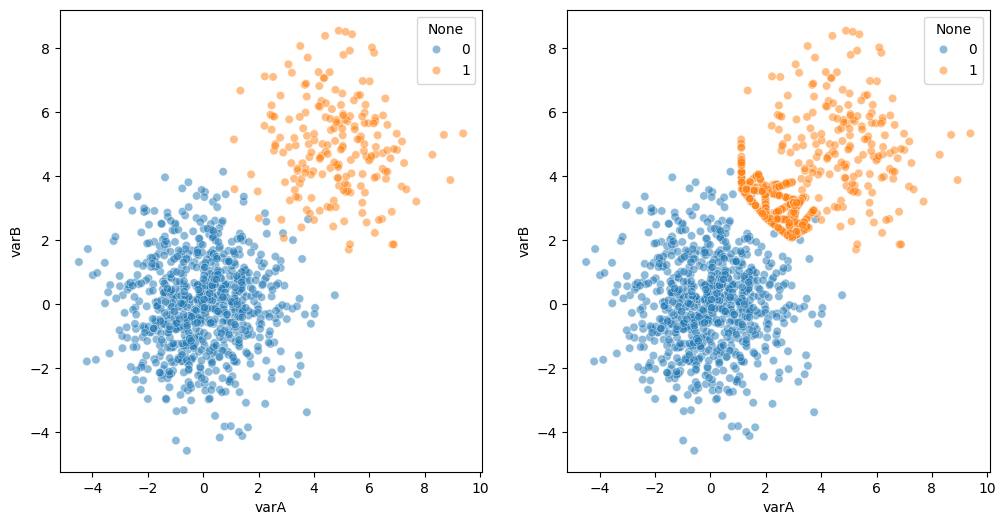

In [38]:
Scatterplot(X, y, X_res_b1, y_res_b1, alpha=0.5)

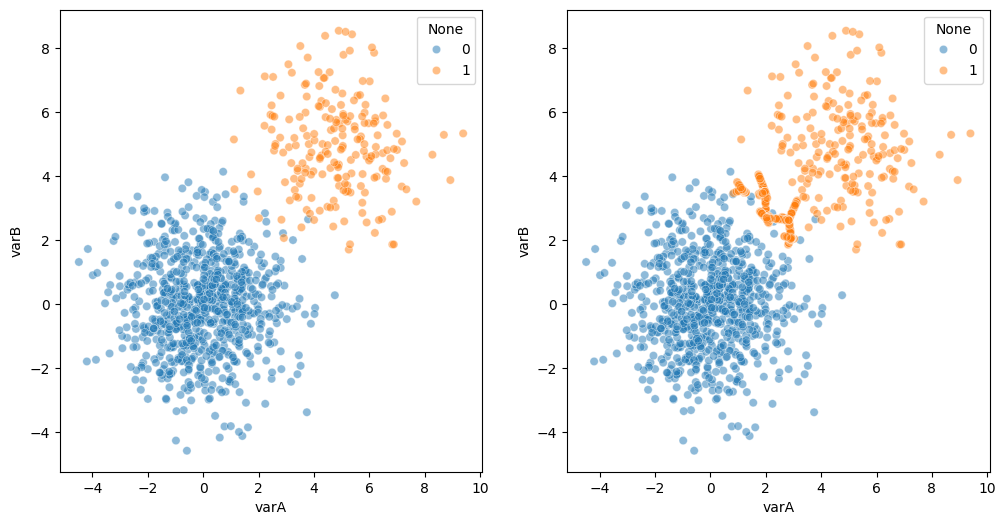

In [41]:
Scatterplot(X, y, X_res_b2, y_res_b2, alpha=0.5)

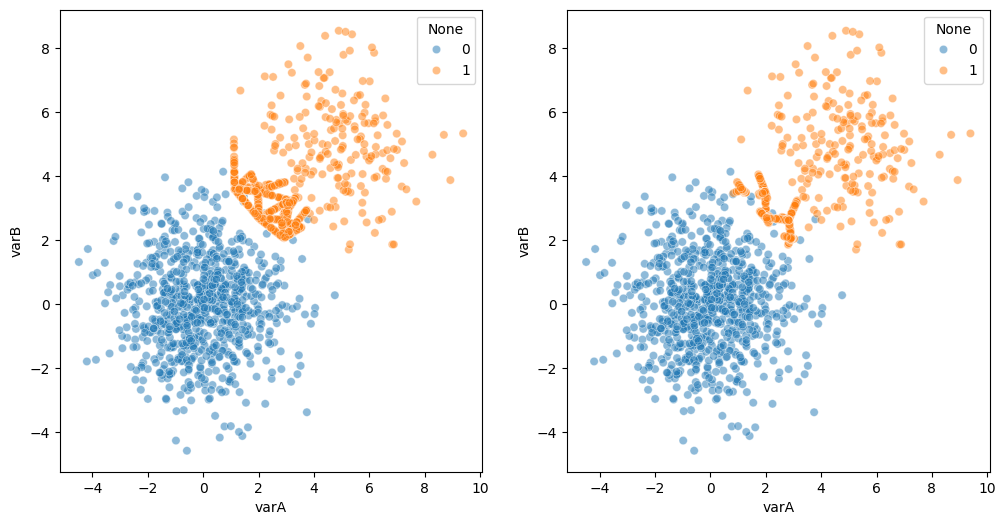

In [40]:
Scatterplot(X_res_b1, y_res_b1, X_res_b2, y_res_b2, alpha=0.5)

We could see there is a strong emphasis on the oversampling along the border between the minority and the majority..
However it's also clear that the emphasis is very different between borderline1 and borderline2.
It seems borderline2 has tighter range for the region that it considers.